In [3]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

In [29]:
import pandas as pd
import numpy as np
import plotly.express as px
import pickle
import re
import string
import emoji
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import multiprocessing
import concurrent.futures
from tqdm.notebook import tqdm
from joblib import Parallel, delayed


import deepcut
from pythainlp.tokenize import word_tokenize
from pythainlp.util import normalize
from pythainlp.spell import correct
from pythainlp.corpus.common import thai_stopwords
import fasttext
import fasttext.util

from argparse import Namespace

In [14]:
FINE_TUNED_DIR = '../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../dataset/reviews'
UTILS_DIR = '../../utils'

In [30]:
args = Namespace(
    VECTOR_SIZE=300,
)

In [13]:
# fasttext.util.download_model('th', if_exists='ignore')
ft = fasttext.load_model('./../pretained_or_finetune-models/cc.th.300.bin') 

In [15]:
tourism_reviews_en = pd.read_parquet(f"{REVIEWS_DATASET_DIR}/TripAdvisor_reviews_TH.parquet")

columns_to_use = ['helpful_votes', 'location_id', 'review_id', 'review',
                  'review_subject', 'trip_type', 'rating',
                  'location_name', 'province', 'place_id', 'emotion', 'cleaned_review']
columns_to_train = ['review_id', 'location_id', 'review_text', 'rating']
review_df = tourism_reviews_en[columns_to_train]

In [16]:
review_df.describe()

,review_id,location_id,rating
count,7.170000e+03,7.170000e+03,7170.000000
mean,6.063747e+08,6.112365e+06,4.369177
std,1.741121e+08,4.311252e+06,0.752342
min,1.322792e+08,3.110380e+05,1.000000
25%,4.608988e+08,2.706887e+06,4.000000
50%,6.376879e+08,5.990445e+06,5.000000
75%,7.409087e+08,8.654056e+06,5.000000
max,9.961066e+08,2.700068e+07,5.000000


In [17]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7170 entries, 0 to 7169
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    7170 non-null   int64 
 1   location_id  7170 non-null   int64 
 2   review_text  7170 non-null   object
 3   rating       7170 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 224.2+ KB


In [18]:
review_df

,review_id,location_id,review_text,rating
0,555329702,456633,การบริการของพนักงานดี ภายในตกแต่งได้สวยงาม และ...,4
1,543783369,456633,เป็นพิพิธภัณฑ์ที่ให้ข้อมูลเกี่ยวกับฝิ่นผูกเรื่...,5
2,349537639,456633,หอฝิ่นเป็นสถานที่ที่ควรไปชมสักครั้งหนึ่ง ค่าเข...,4
3,347878221,456633,เป็นพิพิธภัณฑ์ที่รวบรวมทุกสิ่งทุกอย่างที่เกี่ย...,4
4,319533650,456633,เราเข้าไปเยี่ยมชมพิพิธภัณฑ์หอฟิ่นเป็นครั้งแรกว...,5
...,...,...,...,...
7165,821852808,23744675,บรรยากาศที่สะพานปลา อ่าวเจ้าหลาวยามเย็นสวยมากๆ...,4
7166,763005073,10266462,เดินมาเรื่อยๆก็ถึงวัดบูรพาราม Ubon ที่ถือเป็นว...,3
7167,398492373,10266462,เป็นอีกวัดหนึ่งในจังหวัดอุบลราชธานีที่มีความสว...,3
7168,364357012,10266462,วัดบูรพาแห่งนี้จะหายากสักหน่อยเพราะอยู่ออกห่าง...,3


In [19]:
STOP_WORDS = set(thai_stopwords())

def clean_text(text):
    """Cleans and tokenizes Thai text using Deepcut"""
    try:
        text = text.lower()  # Convert to lowercase
        text = re.sub(r'\d+', '', text)  # Remove numbers
        text = re.sub(r'[^ก-๙a-zA-Z\s]', '', text)  # Remove special characters
        text = normalize(text)  # Normalize Thai text
        text = emoji.demojize(text)  # Convert emojis to text descriptions
        text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
        
        # Use Deepcut for Tokenization
        tokens = deepcut.tokenize(text)
        
        # Remove stop words
        tokens = [word for word in tokens if word not in STOP_WORDS]

        return ' '.join(tokens)
    
    except Exception as e:
        print(f"Error processing text: {text} -> {e}")
        raise e  # Force stop the pool


def parallel_clean_texts(texts, num_workers=2):
    return Parallel(n_jobs=num_workers)(delayed(clean_text)(text) for text in tqdm(texts))

In [20]:
review_df['text_length'] = review_df['review_text'].apply(len)

# Create an interactive histogram using Plotly
fig = px.histogram(
    review_df, 
    x='text_length', 
    nbins=50,  # Adjust the number of bins
    title="Distribution of Review Text Lengths",
    labels={'text_length': 'Review Text Length'},
    opacity=0.7
)

# Update layout for better visualization
fig.update_layout(
    bargap=0.2, 
    xaxis_title="Review Text Length", 
    yaxis_title="Frequency", 
    template="plotly_white"
)

fig.show()

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_15363/4276488930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['text_length'] = review_df['review_text'].apply(len)


In [21]:
# Apply preprocessing to the review texts
# review_df['cleaned_review'] = review_df['review_text'].apply(advanced_clean_text)
# review_df['cleaned_review'] = review_df['review_text'].apply(clean_text)
review_df['cleaned_review'] = parallel_clean_texts(review_df['review_text'].tolist(), num_workers=2)


# 2. สร้าง Word Embeddings ด้วย Word2Vec
# word2vec_model = Word2Vec(sentences=review_df['cleaned_review'], vector_size=300, window=5, min_count=1, sg=1)  # ใช้ Skip-Gram
# sentences = [row.split() for row in review_df['cleaned_review']]
# word2vec_model = Word2Vec(sentences, vector_size=300, window=5, min_count=1, workers=4)  # เปลี่ยน vector_size เป็น 300


  0%|          | 0/7170 [00:00<?, ?it/s]

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.p

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step ep
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step e
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step p
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step e
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Pro

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━

...

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_15363/1039476501.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [22]:
# review_df.to_parquet("./SVM_TH_Cleaned_Data.parquet", engine="pyarrow", compression="zstd")
review_df

,review_id,location_id,review_text,rating,text_length,cleaned_review
0,555329702,456633,การบริการของพนักงานดี ภายในตกแต่งได้สวยงาม และ...,4,125,บริการ พนักงาน ดี ตกแต่ง สวยงาม รู้ บรรย...
1,543783369,456633,เป็นพิพิธภัณฑ์ที่ให้ข้อมูลเกี่ยวกับฝิ่นผูกเรื่...,5,297,พิพิธภัณฑ์ ข้อมูล เกี่ยว ฝิ่น ผูก เรื่อง อารยธ...
2,349537639,456633,หอฝิ่นเป็นสถานที่ที่ควรไปชมสักครั้งหนึ่ง ค่าเข...,4,298,หอ ฝิ่น สถานที่ ชม สัก ค่า ชม คน ไทย บาท ...
3,347878221,456633,เป็นพิพิธภัณฑ์ที่รวบรวมทุกสิ่งทุกอย่างที่เกี่ย...,4,107,พิพิธภัณฑ์ รวบรวม ทุกสิ่งทุกอย่าง เกี่ยว ปลูกฝ...
4,319533650,456633,เราเข้าไปเยี่ยมชมพิพิธภัณฑ์หอฟิ่นเป็นครั้งแรกว...,5,243,เยี่ยมชม พิพิธภัณฑ์หอฟิ่น วิว รอบ หอ สวยงาม ค่...
...,...,...,...,...,...,...
7165,821852808,23744675,บรรยากาศที่สะพานปลา อ่าวเจ้าหลาวยามเย็นสวยมากๆ...,4,615,บรรยากาศ สะพานปลา อ่าวเจ้าหลาวยาม เย็น สวย ...
7166,763005073,10266462,เดินมาเรื่อยๆก็ถึงวัดบูรพาราม Ubon ที่ถือเป็นว...,3,176,เดิน วัดบูรพาราม ubon วัด ต้น กำเนิด สายวิ...
7167,398492373,10266462,เป็นอีกวัดหนึ่งในจังหวัดอุบลราชธานีที่มีความสว...,3,102,วัด จังหวัดอุบลราชธานี สวยงาม ตัวเมือง อุบล ...
7168,364357012,10266462,วัดบูรพาแห่งนี้จะหายากสักหน่อยเพราะอยู่ออกห่าง...,3,246,วัดบูรพา หา สัก ห่าง เมือง ทิศ ตะวัน วัด รู้...


In [23]:
def map_rating_to_sentiment(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positive'

# Apply the mapping to your DataFrame
review_df['sentiment'] = review_df['rating'].apply(map_rating_to_sentiment)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_15363/3932828178.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [25]:
# Transform the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(review_df['cleaned_review']).toarray()

# Tokenize the cleaned reviews for Word2Vec
review_df['tokens'] = review_df['cleaned_review'].apply(lambda x: x.split())



/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_15363/2614387721.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [31]:
def compute_avg_fasttext(tokens, model):
    vector_size = args.VECTOR_SIZE  # FastText model has a fixed vector size (default: 300)
    avg_vector = np.zeros(vector_size)
    count = 0
    
    for word in tokens:
        vector = model.get_word_vector(word)  # FastText vector retrieval
        avg_vector += vector
        count += 1
    
    if count != 0:
        avg_vector /= count  # Average the vectors
    
    return avg_vector

In [32]:
# Compute Word2Vec embeddings for each review
review_df['fasttext_embedding'] = review_df['tokens'].apply(lambda x: compute_avg_fasttext(x, ft))

# Combine TF-IDF vectors with Word2Vec embeddings
X_combined = np.hstack((X_tfidf, np.vstack(review_df['fasttext_embedding'].values)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, review_df['sentiment'], test_size=0.2, random_state=42)


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_15363/2488621614.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [34]:
review_df[['cleaned_review', 'tokens', 'fasttext_embedding']]

,cleaned_review,tokens,fasttext_embedding
0,บริการ พนักงาน ดี ตกแต่ง สวยงาม รู้ บรรย...,"[บริการ, พนักงาน, ดี, ตกแต่ง, สวยงาม, รู้, บรร...","[-0.009105444652959704, 0.0022350302897393703,..."
1,พิพิธภัณฑ์ ข้อมูล เกี่ยว ฝิ่น ผูก เรื่อง อารยธ...,"[พิพิธภัณฑ์, ข้อมูล, เกี่ยว, ฝิ่น, ผูก, เรื่อง...","[0.0052106502250983166, -0.014473794843070209,..."
2,หอ ฝิ่น สถานที่ ชม สัก ค่า ชม คน ไทย บาท ...,"[หอ, ฝิ่น, สถานที่, ชม, สัก, ค่า, ชม, คน, ไทย,...","[0.010494383648619987, 0.041658732829091605, 0..."
3,พิพิธภัณฑ์ รวบรวม ทุกสิ่งทุกอย่าง เกี่ยว ปลูกฝ...,"[พิพิธภัณฑ์, รวบรวม, ทุกสิ่งทุกอย่าง, เกี่ยว, ...","[-0.013336925586271618, 0.006805135001842346, ..."
4,เยี่ยมชม พิพิธภัณฑ์หอฟิ่น วิว รอบ หอ สวยงาม ค่...,"[เยี่ยมชม, พิพิธภัณฑ์หอฟิ่น, วิว, รอบ, หอ, สวย...","[-0.00027460692393960375, 0.01901392311309323,..."
...,...,...,...
7165,บรรยากาศ สะพานปลา อ่าวเจ้าหลาวยาม เย็น สวย ...,"[บรรยากาศ, สะพานปลา, อ่าวเจ้าหลาวยาม, เย็น, สว...","[0.006090341754776391, 0.014309787499895938, 0..."
7166,เดิน วัดบูรพาราม ubon วัด ต้น กำเนิด สายวิ...,"[เดิน, วัดบูรพาราม, ubon, วัด, ต้น, กำเนิด, สา...","[0.002365410909987986, 0.0036781914698492202, ..."
7167,วัด จังหวัดอุบลราชธานี สวยงาม ตัวเมือง อุบล ...,"[วัด, จังหวัดอุบลราชธานี, สวยงาม, ตัวเมือง, อุ...","[-0.0034856322781706695, 0.0032182306385948323..."
7168,วัดบูรพา หา สัก ห่าง เมือง ทิศ ตะวัน วัด รู้...,"[วัดบูรพา, หา, สัก, ห่าง, เมือง, ทิศ, ตะวัน, ว...","[0.004704591915166627, 0.010217820386363504, 0..."


In [35]:
# Create a pipeline with SMOTE, Random Undersampling, and SVM with Class Weights
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),  # Apply SMOTE to oversample minority classes
    ('undersample', RandomUnderSampler(random_state=42)),  # Apply Random Undersampling to balance the majority class
    ('scaler', StandardScaler()),  # Normalize features
    ('svm', SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))  # SVM with class weights
])

In [36]:
# Train the model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('undersample', RandomUnderSampler(random_state=42)),
                ('scaler', StandardScaler()),
                ('svm',
                 SVC(class_weight='balanced', kernel='linear',
                     random_state=42))])

In [39]:

with open('./SVN_TH_Sentiment_model.pkl', 'wb') as file:
    pickle.dump(pipeline, file)
    
# with open('../../models/SVN_model_sample.pkl', 'rb') as file:
#     pipeline = pickle.load(file)

In [37]:
# Check the shapes of the resulting arrays
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (5736, 13125)
y_train shape: (5736,)
X_test shape: (1434, 13125)
y_test shape: (1434,)


In [38]:
# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

    negative       0.43      0.45      0.44        20
     neutral       0.15      0.20      0.17       147
    positive       0.90      0.86      0.88      1267

    accuracy                           0.78      1434
   macro avg       0.49      0.50      0.50      1434
weighted avg       0.81      0.78      0.80      1434

Confusion Matrix:
[[   9    4    7]
 [   1   30  116]
 [  11  172 1084]]


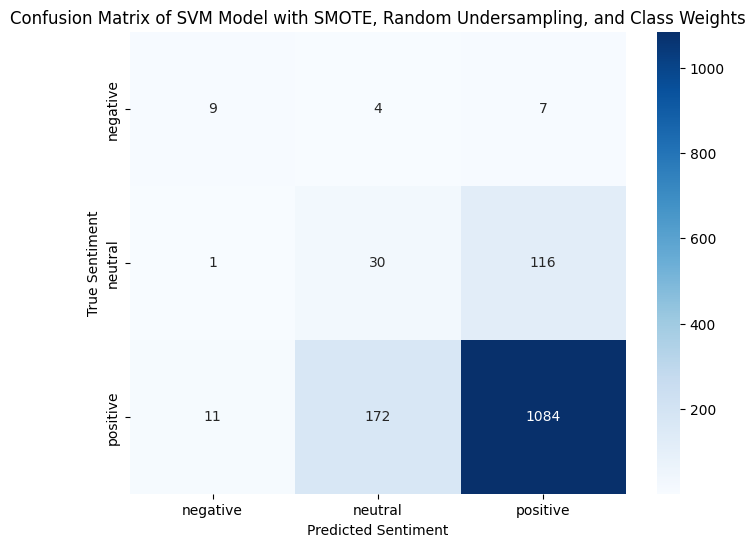

In [40]:
# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix of SVM Model with SMOTE, Random Undersampling, and Class Weights')
plt.show()

In [41]:
# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Precision: 0.8144
Recall: 0.7831
F1-Score: 0.7978


In [42]:
y_pred

array(['positive', 'positive', 'positive', ..., 'positive', 'positive',
       'positive'], dtype=object)

In [43]:
y_test

2486    negative
4348    positive
4251    positive
2877     neutral
4639    positive
          ...   
3984     neutral
3544    positive
4233    positive
6425    positive
4710    positive
Name: sentiment, Length: 1434, dtype: object

In [ ]:

predictions_df = pd.DataFrame({
    "review_id": review_df.loc[y_test.index, 'review_id'],
    "location_id": review_df.loc[y_test.index, 'location_id'],
    'review_text': review_df.loc[y_test.index, 'review_text'],  # Assuming X_test is a subset with a specific index
    'actual_sentiment': y_test,  # The actual sentiment labels
    'predicted_sentiment': y_pred  # The predicted sentiment labels
})


predictions_df.head(10)


,review_id,location_id,review_text,actual_sentiment,predicted_sentiment
2486,348828734,2038063,ได้มีโอกาสเข้าไปเยี่ยมชมช้างที่นี่ แต่ไม่ค่อยไ...,negative,positive
4348,836223824,6668967,วัดจุฬามณี เป็นวัดเก่าแก่อีกแห่งหนึ่งของจังหวั...,positive,positive
4251,670545800,7923675,บริเวณพญานาคจะมองเห็นฝั่งโขง ด้านตรงข้ามพญานาค...,positive,positive
2877,411055316,6669327,เมื่อใดก็ตามที่ไปจังหวัดต่างๆ แนะนำเข้าไปสักกา...,neutral,positive
4639,749620940,14183193,ศูนย์รวมอุปกรณ์ไอที ที่มีครบทุกอย่าง เคยไปซื้อ...,positive,positive
2155,921184170,17595960,เด็กๆชอบมากๆ มาใช้บริการหลายครั้งแล้ว เดินทางม...,positive,positive
1535,622268127,10084886,ซฮยรามบุตรีมีร้านนั่งชิลเยอะะะะ คนไม่วุ่นวายเท...,positive,positive
1817,547773254,7084940,หากมาเที่ยวกรุงเทพมหานคร แล้วอยากหาชมพิพิธภัณฑ...,positive,neutral
6903,426031409,2000958,บ้านควาญช้างดิชั้นไปเที่ยวได้ขึ้นขี่บนหลังช้าง...,negative,positive
3497,732281848,4787586,มาแวะเที่ยวที่วัดน้ำฮู เป็นวัดที่เก่าแก่ของเมื...,positive,neutral


In [54]:
predictions_df.to_csv("../prediction/SVN_Prediction.csv", index=False)